In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')
sns.set_palette('viridis')

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("processed_data.csv")
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_contacted_before', 'pdays_clean', 'age_group',
       'month_contact'],
      dtype='str')

In [5]:
df.shape

(41176, 23)

## Preprocessing Pipeline

In [6]:
final_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 
                  'campaign', 'previous', 'poutcome','emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
                  'nr.employed', 'was_contacted_before', 'pdays_clean','age_group','month_contact']

target_col = 'y'

df_model = df[final_features + [target_col]].copy()
df_model.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,pdays_clean,age_group,month_contact,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,56-65,may_telephone,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,56-65,may_telephone,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,36-45,may_telephone,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,36-45,may_telephone,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,56-65,may_telephone,no


### Train/Test (Stratified Split)

In [7]:
from sklearn.model_selection import train_test_split
x = df_model.drop(columns = [target_col])
y = (df_model[target_col].astype(str)=='yes').astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 42)

### ColumnTransformer

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                     'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_clean']
binary_features = ['was_contacted_before']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                         'contact', 'month', 'day_of_week', 'poutcome', 'month_contact']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features)
])

In [9]:
x_train_transformed = preprocessor.fit_transform(x_train)
feature_names_out = preprocessor.get_feature_names_out()

print(f"shape: {x_train_transformed.shape}")
print(f"total features name: {len(feature_names_out)}")

shape: (32940, 72)
total features name: 72


## Model Building

In this section, multiple classification models are trained to compare their predictive performance in the subsequent stages of the project. 
    Each model follows a different learning approach:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost / LightGBM / CatBoost

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Positive Class Weight (for Boosting Models): {scale_pos_weight:.2f}")

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                                              random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                               scale_pos_weight=scale_pos_weight, random_state=42,
                               eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                 class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostClassifier(iterations=300, depth=5, learning_rate=0.1,
                                     auto_class_weights='Balanced', random_state=42, verbose=0)
}

print("Defined Models:", list(models.keys()))

Positive Class Weight (for Boosting Models): 7.88
Defined Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


In [11]:
trained_pipelines = {}
training_times = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    start = time.time()
    pipe.fit(x_train, y_train)
    elapsed = time.time() - start
    trained_pipelines[name] = pipe
    training_times[name] = elapsed
    print(f"{name:22s} | Training Time: {elapsed:.2f} seconds")

Logistic Regression    | Training Time: 0.34 seconds
Decision Tree          | Training Time: 0.28 seconds
Random Forest          | Training Time: 1.90 seconds
XGBoost                | Training Time: 0.66 seconds
LightGBM               | Training Time: 0.37 seconds
CatBoost               | Training Time: 2.09 seconds


## Model Evaluation

In [43]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                                roc_auc_score, average_precision_score, confusion_matrix,
                                roc_curve, precision_recall_curve, classification_report)

def evaluate_model(name, pipe, X_tr, y_tr, X_te, y_te):
    y_pred_tr = pipe.predict(X_tr)
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    return {
        'Model': name,
        'Train Accuracy': accuracy_score(y_tr, y_pred_tr),
        'Test Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba),
        'PR-AUC': average_precision_score(y_te, y_proba),
    }

results = []
for name, pipe in trained_pipelines.items():
    res = evaluate_model(name, pipe, x_train, y_train, x_test, y_test)
    res['Training Time (s)'] = training_times.get(name, np.nan)
    results.append(res)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Training Time (s)
0,Random Forest,0.873831,0.866440,0.434451,0.614224,0.508929,0.812323,0.481947,1.941580
1,CatBoost,0.847450,0.842885,0.384177,0.654095,0.484051,0.808388,0.482061,2.068493
2,Logistic Regression,0.827262,0.829407,0.358625,0.651940,0.462715,0.802101,0.448175,0.339881
3,LightGBM,0.858956,0.846163,0.389432,0.643319,0.485169,0.800048,0.470850,0.370489
4,XGBoost,0.860808,0.845799,0.389249,0.647629,0.486246,0.798303,0.461802,0.558447
5,Decision Tree,0.826108,0.831472,0.364066,0.663793,0.470229,0.793491,0.452729,0.278666


**Random Forest** and **CatBoost** were selected for hyperparameter tuning because they demonstrated the strongest overall performance among the evaluated models. Random Forest achieved the highest F1-score while maintaining a competitive ROC-AUC, indicating a good balance between precision and recall. CatBoost was selected as the boosting-based model due to its competitive ROC-AUC and the highest PR-AUC, making it a strong candidate for further optimization on this imbalanced classification task.

## Hyperparameter Tuning

In [44]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_param_dist = {
    'classifier__n_estimators': [150, 250, 350],
    'classifier__max_depth': [6, 8, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', RandomForestClassifier(class_weight='balanced',
                                                                    random_state=42, n_jobs=-1))])

rf_search = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=5, scoring='roc_auc',
                                 cv=cv_strategy, random_state=42, n_jobs=-1, verbose=0)
start = time.time()
rf_search.fit(x_train, y_train)

print("best params:", rf_search.best_params_)
print(f"best score ROC-AUC (CV): {rf_search.best_score_:.4f}")

best params: {'classifier__n_estimators': 350, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}
best score ROC-AUC (CV): 0.7973


In [45]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import time

cat_param_dist = {
    'classifier__iterations': [200, 300, 500],
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__l2_leaf_reg': [1, 3, 5, 7],
    'classifier__subsample': [0.8, 1.0]
}

cat_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        auto_class_weights='Balanced',
        random_state=42,
        verbose=0
    ))
])

cat_search = RandomizedSearchCV(
    estimator=cat_pipe,
    param_distributions=cat_param_dist,
    n_iter=5,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

start = time.time()
cat_search.fit(x_train, y_train)

elapsed = time.time() - start

print("Best Params:", cat_search.best_params_)
print(f"Best ROC-AUC (CV): {cat_search.best_score_:.4f}")
print(f"Training Time: {elapsed:.2f} seconds")

Best Params: {'classifier__subsample': 0.8, 'classifier__learning_rate': 0.03, 'classifier__l2_leaf_reg': 7, 'classifier__iterations': 500, 'classifier__depth': 6}
Best ROC-AUC (CV): 0.7963
Training Time: 31.68 seconds


In [46]:
trained_pipelines['Random Forest (Tuned)'] = rf_search.best_estimator_
trained_pipelines['CatBoost (Tuned)'] = cat_search.best_estimator_

print(list(trained_pipelines.keys()))

['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Random Forest (Tuned)', 'CatBoost (Tuned)']


In [47]:
results = []
for name, pipe in trained_pipelines.items():
    res = evaluate_model(name, pipe, x_train, y_train, x_test, y_test)
    res['Training Time (s)'] = training_times.get(name, np.nan)
    results.append(res)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Training Time (s)
0,Random Forest,0.873831,0.866440,0.434451,0.614224,0.508929,0.812323,0.481947,1.941580
1,CatBoost (Tuned),0.841469,0.842642,0.384131,0.657328,0.484897,0.811725,0.479813,NaN
2,Random Forest (Tuned),0.852368,0.855270,0.408840,0.637931,0.498316,0.811135,0.480924,NaN
3,CatBoost,0.847450,0.842885,0.384177,0.654095,0.484051,0.808388,0.482061,2.068493
4,Logistic Regression,0.827262,0.829407,0.358625,0.651940,0.462715,0.802101,0.448175,0.339881
5,LightGBM,0.858956,0.846163,0.389432,0.643319,0.485169,0.800048,0.470850,0.370489
6,XGBoost,0.860808,0.845799,0.389249,0.647629,0.486246,0.798303,0.461802,0.558447
7,Decision Tree,0.826108,0.831472,0.364066,0.663793,0.470229,0.793491,0.452729,0.278666


### ROC curve analysis

For ROC curve analysis, three representative models are selected: **Logistic Regression, Random Forest**, and **CatBoost**. These models represent different learning paradigms (linear, bagging, and boosting), allowing a comprehensive comparison of their classification performance.

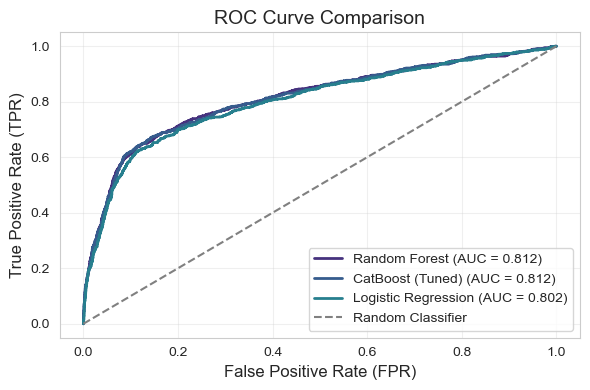

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

selected_models = [
    'Random Forest',
    'CatBoost (Tuned)',
    'Logistic Regression'
]

plt.figure(figsize=(6, 4))
for name in selected_models:
    model = trained_pipelines[name]
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot(
    [0, 1], [0, 1],
    linestyle='--',
    color='gray',
    linewidth=1.5,
    label='Random Classifier'
)

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**The ROC curves indicate** that all three models achieve good discriminative performance, with AUC values above 0.80. Random Forest achieved the highest ROC-AUC (0.813), closely followed by CatBoost (0.812), while Logistic Regression obtained a slightly lower AUC (0.802). The small differences between the curves suggest that all models have a similar ability to distinguish between subscribers and non-subscribers.

### Precision–Recall curves Analysis

Since the dataset is imbalanced, Precision–Recall curves are generated for the two best-performing models, Random Forest and CatBoost. These models achieved the strongest overall performance and are therefore selected for a more detailed evaluation using Precision–Recall analysis.

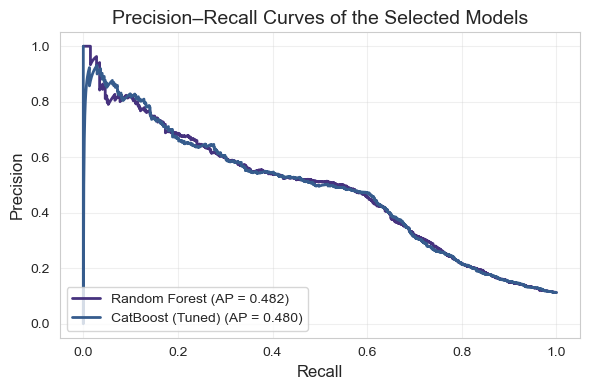

In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Models to compare
selected_models = [
    'Random Forest',
    'CatBoost (Tuned)'
]

plt.figure(figsize=(6, 4))
for name in selected_models:
    model = trained_pipelines[name]
    y_prob = model.predict_proba(x_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f'{name} (AP = {ap:.3f})'
    )

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision–Recall Curves of the Selected Models', fontsize=14)
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**The Precision–Recall curves show** that both Random Forest and the tuned CatBoost model perform very similarly on the imbalanced dataset, with Average Precision (AP) scores of 0.481 and 0.479, respectively. The nearly overlapping curves indicate that both models maintain a comparable balance between precision and recall across different classification thresholds.

As expected, precision decreases as recall increases, reflecting the trade-off between identifying more positive cases and reducing false positives. Since the performance difference between the two models is minimal, the final model selection can also consider factors such as training time, computational efficiency, and model interpretability in addition to predictive performance.

### Final Model Selection

Although CatBoost achieved competitive performance, Random Forest delivered the best overall balance across ROC-AUC, F1-score, and precision while maintaining lower model complexity and easier interpretability. Therefore, Random Forest was selected as the final model for deployment.

### Built-in Feature Importance

In [54]:
def plot_feature_importance(model, feature_names, model_name="Model", top_n=20):
    
    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(data=importance_df, x="Importance", y="Feature")

    plt.title(
        f"Top {top_n} Feature Importances - {model_name}",
        fontsize=14
    )
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f")

    plt.tight_layout()
    plt.show()
    return importance_df

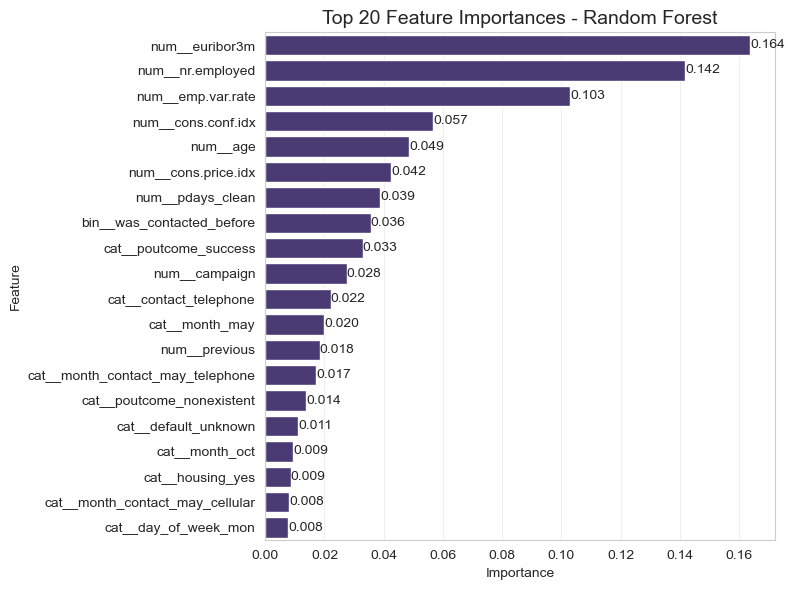

,Feature,Importance
6,num__euribor3m,0.163879
7,num__nr.employed,0.141796
3,num__emp.var.rate,0.102979
5,num__cons.conf.idx,0.056793
0,num__age,0.048693
4,num__cons.price.idx,0.042442
8,num__pdays_clean,0.038791
9,bin__was_contacted_before,0.035571
52,cat__poutcome_success,0.032861
1,num__campaign,0.027561


In [55]:
best_model = trained_pipelines['Random Forest'].named_steps['classifier']

importance_df = plot_feature_importance(
    model=best_model,
    feature_names=feature_names_out,
    model_name="Random Forest",
    top_n=20
)

importance_df

The model relies mainly on macroeconomic indicators and previous customer interactions for prediction. Features such as euribor3m, nr.employed, and emp.var.rate have the highest importance, highlighting the role of economic conditions in customer subscription decisions. Previous campaign outcomes and contact history also contribute significantly, showing the importance of past customer interactions.

### Permutation Importance

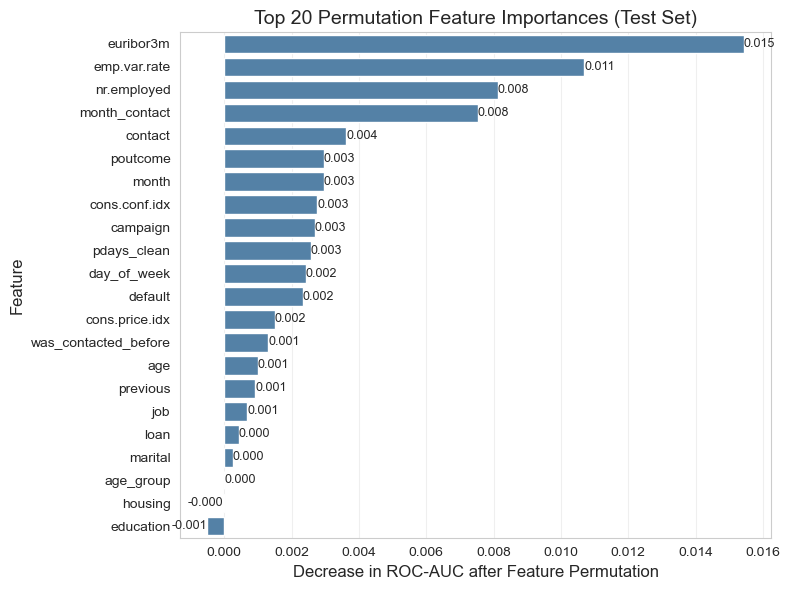

,Feature,Importance
16,euribor3m,0.015434
13,emp.var.rate,0.010689
17,nr.employed,0.008118
21,month_contact,0.007530
7,contact,0.003625
12,poutcome,0.002953
8,month,0.002951
15,cons.conf.idx,0.002764
10,campaign,0.002692
19,pdays_clean,0.002567


In [61]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

best_pipe = trained_pipelines['Random Forest']

perm_result = permutation_importance(
    estimator=best_pipe,
    X=x_test,
    y=y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_importance = (
    pd.DataFrame({
        'Feature': x_test.columns,
        'Importance': perm_result.importances_mean
    })
    .sort_values('Importance', ascending=False)
)

top_features = perm_importance.head(23)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    color='steelblue'
)

plt.title('Top 20 Permutation Feature Importances (Test Set)', fontsize=14)
plt.xlabel('Decrease in ROC-AUC after Feature Permutation', fontsize=12)
plt.ylabel('Feature', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.show()

top_features

**Permutation Importance shows** that euribor3m, emp.var.rate, and nr.employed are the most influential features, as shuffling these variables causes the largest decrease in model performance. Features related to campaign timing and previous customer interactions, such as month_contact, poutcome, and pdays_clean, also contribute significantly to prediction.

In contrast, demographic features such as job, marital, housing, and loan have a relatively limited impact on model performance.

**Note:** The agreement between Permutation Importance and Built-in Feature Importance for features such as euribor3m, emp.var.rate, nr.employed, and pdays_clean suggests that these variables genuinely contribute to the model’s predictive performance rather than being important only due to the internal structure of the Random Forest model.

## SHAP Analysis

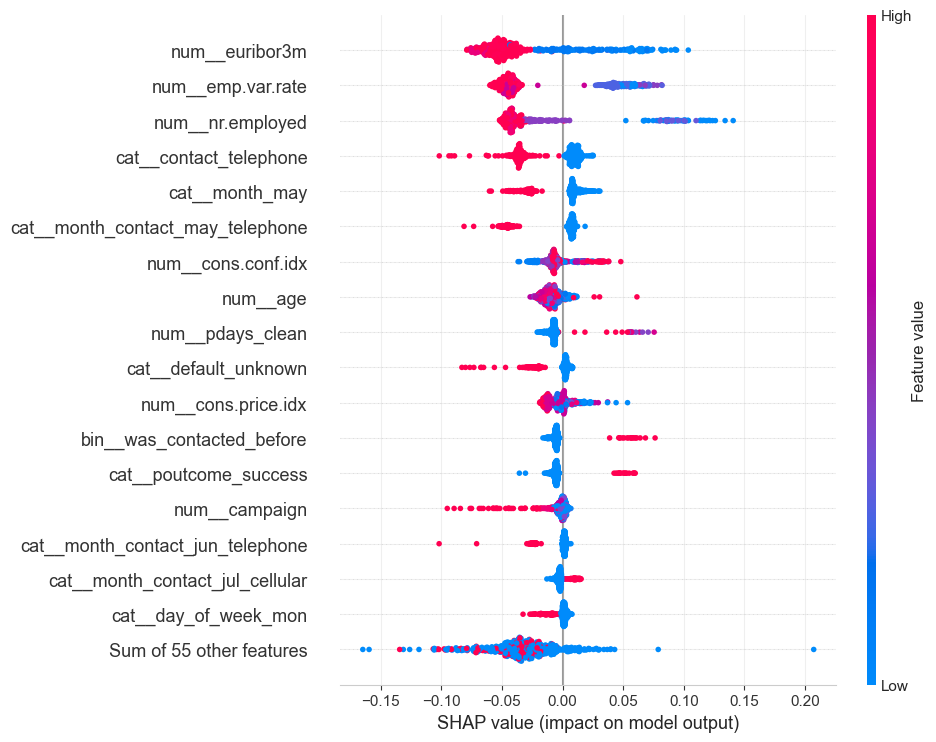

In [62]:
import shap
best_pipe = trained_pipelines['Random Forest']

preprocessor = best_pipe.named_steps['preprocessor']
rf_model = best_pipe.named_steps['classifier']

X_test_processed = preprocessor.transform(x_test)

feature_names = preprocessor.get_feature_names_out()

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=x_test.index
)

X_sample = X_test_processed.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_sample)

shap.plots.beeswarm(
    shap_values[:, :, 1],
    max_display=18
)

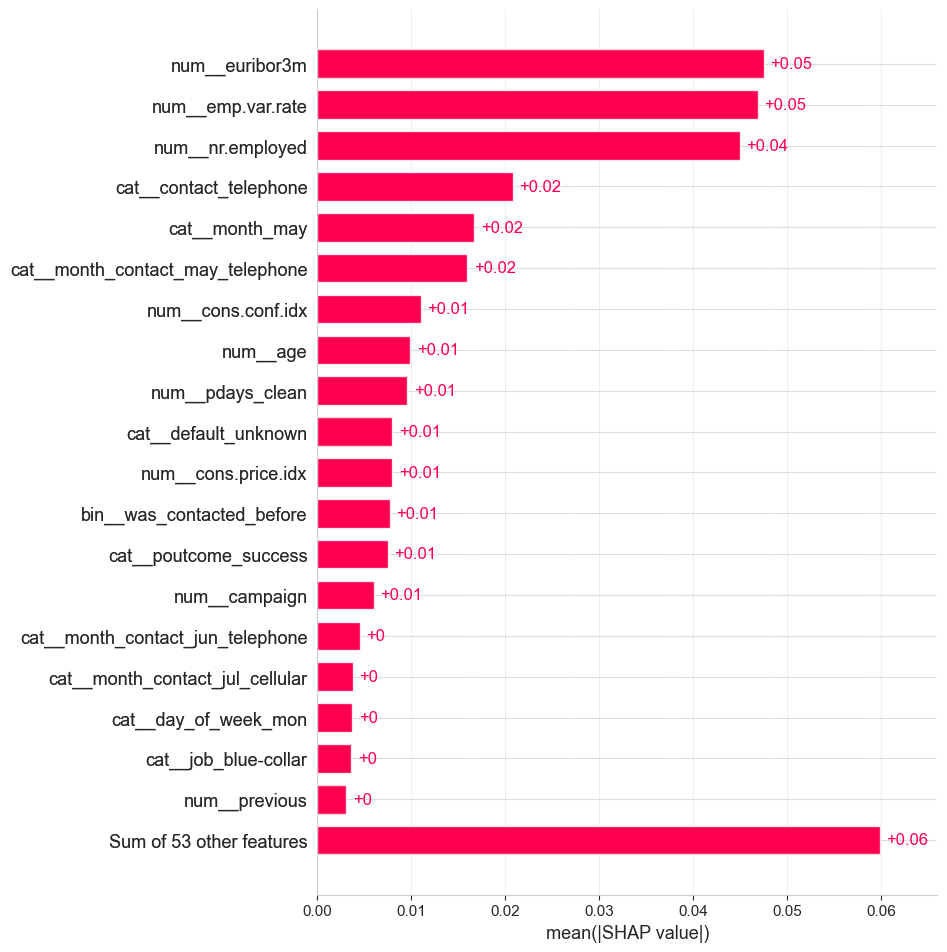

In [56]:
shap.plots.bar(
    shap_values[:, :, 1],
    max_display=20
)

The combined results of Built-in Feature Importance, Permutation Importance, and SHAP Analysis show that the Random Forest model mainly relies on three groups of features for predicting term deposit subscription: macroeconomic indicators, previous customer interactions, and campaign-related attributes.

Across all three methods, economic variables such as euribor3m, emp.var.rate, and nr.employed consistently appear among the most important features, highlighting the role of macroeconomic conditions in customer behavior. Additionally, previous interaction features such as poutcome_success and pdays_clean provide valuable predictive information, indicating the importance of past customer engagement.

Campaign-related features, including contact method, campaign timing, and number of contacts, also influence model predictions, while demographic features such as job, marital, housing, and loan have a relatively smaller impact.

The consistency between the three interpretation methods increases confidence that the identified features genuinely contribute to model performance. These insights can support more targeted marketing campaigns and help prioritize customers with a higher probability of subscription.

Note: Feature importance and SHAP values indicate how much each feature contributes to the model’s predictions; they do not establish a causal relationship with customer behavior.

### Logistic Regression Coefficient

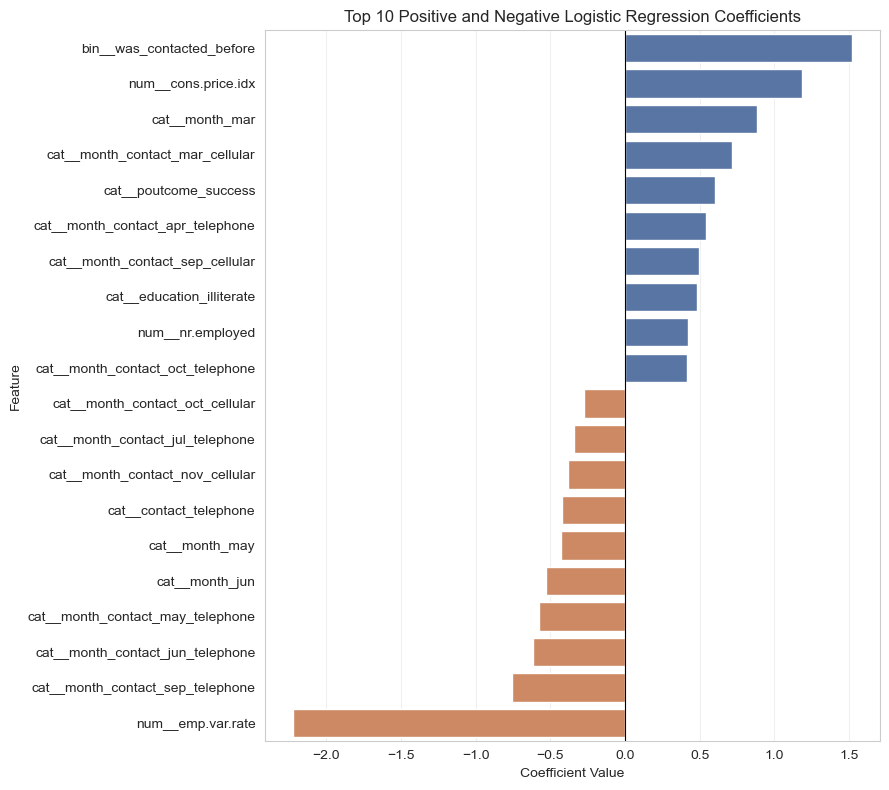

Top 10 features increasing subscription probability:
                         feature  coefficient  odds_ratio
       bin__was_contacted_before     1.519421    4.569578
             num__cons.price.idx     1.185301    3.271671
                  cat__month_mar     0.883658    2.419736
 cat__month_contact_mar_cellular     0.716495    2.047246
           cat__poutcome_success     0.603524    1.828551
cat__month_contact_apr_telephone     0.539149    1.714547
 cat__month_contact_sep_cellular     0.497725    1.644975
       cat__education_illiterate     0.479009    1.614473
                num__nr.employed     0.420733    1.523077
cat__month_contact_oct_telephone     0.412144    1.510052

Top 10 features decreasing subscription probability:
                         feature  coefficient  odds_ratio
 cat__month_contact_oct_cellular    -0.276088    0.758746
cat__month_contact_jul_telephone    -0.338475    0.712856
 cat__month_contact_nov_cellular    -0.379098    0.684478
          cat__contact_

In [63]:
lr_pipe = trained_pipelines['Logistic Regression']
lr_coefs = lr_pipe.named_steps['classifier'].coef_[0]
lr_feature_names = lr_pipe.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': lr_feature_names,
    'coefficient': lr_coefs
})

coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

coef_df = coef_df.sort_values('coefficient', ascending=False)

top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)

top_combined = pd.concat([top_positive, top_negative])

plt.figure(figsize=(9, 8))

colors = [
    '#4C72B0' if c > 0 else '#DD8452'
    for c in top_combined['coefficient']
]

sns.barplot(
    x='coefficient',
    y='feature',
    data=top_combined,
    palette=colors
)

plt.title('Top 10 Positive and Negative Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


print("Top 10 features increasing subscription probability:")
print(
    top_positive[['feature', 'coefficient', 'odds_ratio']]
    .to_string(index=False)
)

print("\nTop 10 features decreasing subscription probability:")
print(
    top_negative[['feature', 'coefficient', 'odds_ratio']]
    .to_string(index=False)
)

**Logistic Regression Coefficient Analysis**

While Feature Importance and SHAP analysis explain which features contribute most to the Random Forest predictions, Logistic Regression coefficients provide additional insight into the direction and magnitude of each feature’s relationship with subscription probability.

The results show that **previous customer engagement** has the strongest positive association with subscription. The feature was_contacted_before has the highest positive effect, with an odds ratio of 4.57, indicating that customers with previous interactions are more likely to subscribe.

Among **economic factors**, emp.var.rate shows the strongest negative association, with an odds ratio of 0.11, suggesting that unfavorable economic conditions are associated with a lower probability of subscription. Campaign timing and contact-related features also show different effects, indicating that the success of marketing campaigns depends not only on customer characteristics but also on how and when customers are contacted.

Overall, Logistic Regression provides a complementary perspective by showing the direction of relationships identified in the previous interpretability analyses.